# 🎯 **But du projet d’analyse du dataset Netflix**
Objectif général : Le but de ce projet est d’analyser le catalogue de contenus proposés par Netflix (films et séries) afin d’en extraire des informations pertinentes, compréhensibles et exploitables. On cherche à mieux comprendre les caractéristiques de l’offre Netflix en fonction des types d'œuvres, des années, des pays, des genres, des durées, etc.

## 📑 **Sommaire du Projet – Analyse du Dataset Netflix**

---

## **1. Introduction**
- Objectif du projet
- Présentation du dataset
- Intérêt de l’analyse

---

## **2. Chargement des données**
- Importation des bibliothèques
- Chargement du dataset avec Pandas

---

## **3. Exploration initiale**
- Aperçu des 5 premières et 5 dernières lignes
- Informations générales du DataFrame (`.info()`)
- Dimensions du dataset (nombre d’observations et de variables)
- Liste des colonnes disponibles
- Types de données (quantitatives vs qualitatives)

---

## **4. Analyse des données manquantes**
- Taux de données manquantes par colonne (en %)
- Visualisation avec la librairie `Missingno`

---

## **5. Nettoyage et préparation des données**
- Conversion de `date_added` au format DateTime
- Extraction de la durée en minutes ou en saisons (`duration_int`)
- Création d’une colonne `duration_type` (minutes ou saisons)
- Transformation de la colonne `listed_in` en liste de genres
- Création éventuelle de colonnes supplémentaires (`year_added`, etc.)

---

## **6. Exploration détaillée**
- Affichage d'une observation aléatoire
- Recherche d’un film spécifique ("Catch Me If You Can")
- Films et séries les plus récents
- Valeurs uniques des variables clés (type, pays, année, rating, genre)
- Réalisateurs les plus prolifiques
- Année avec le plus de films ajoutés
- Année avec le plus de séries ajoutées

---

## **7. Visualisations avec Matplotlib, Seaborn, Plotly**
a. Répartition des types d'œuvres  
b. Répartition des œuvres par pays  
c. Répartition des œuvres par année  
d. Répartition par classification (rating)  
e. Distribution de la durée des films  
f. Distribution de la durée des séries  
g. Répartition des genres d’œuvres  
h. Top 5 des séries les plus longues  
i. Top 5 des films les plus longs  
j. Répartition des réalisateurs français  
k. Répartition par date d’ajout au catalogue  
l. Toute autre visualisation pertinente

---

## **8. Analyse des résultats**
- Analyse descriptive des données observées
- Interprétation des tendances
- Mise en évidence de patterns intéressants

---

## **9. Conclusion**
- Synthèse des découvertes
- Limites de l’analyse
- Pistes pour une future analyse (ex : prédictions, recommandations)


🔧 Étape 0 : Importer les bibliothèques et charger le dataset

In [9]:
import pandas as pd
import matplotlib as plt
import seaborn as sns

df = pd.read_csv("netflix_titles.csv")

🔎 Étape 4 : Aperçu du DataFrame

In [10]:
print(df.head())  
print(df.tail())  

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

ℹ️ Étape 5 : Informations générales du DataFrame

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


📐 Étape 6 : Dimensionnalité du DataFrame

In [12]:
print("Nombre de lignes (observations) :", df.shape[0])
print("Nombre de colonnes (variables) :", df.shape[1])

Nombre de lignes (observations) : 8807
Nombre de colonnes (variables) : 12


🏷️ Étape 7 : Afficher les colonnes

In [13]:
print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


🔠 Étape 8 : Types de données

In [14]:
print(df.dtypes)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


❓ Étape 9 : Données manquantes en %

In [15]:
missing_percent = df.isnull().mean() * 100
print(missing_percent)

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


📉 Étape 10 : Visualisation des données manquantes

In [16]:
missing_percent = df.isnull().mean() * 100

missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

print("Pourcentage de valeurs manquantes par colonne :")
print(missing_percent)

Pourcentage de valeurs manquantes par colonne :
director      29.908028
country        9.435676
cast           9.367549
date_added     0.113546
rating         0.045418
duration       0.034064
dtype: float64


🎲 Étape 11 : Observation aléatoire

In [17]:
print(df.sample(1))

    show_id   type              title        director  \
202    s203  Movie  Kyaa Kool Hai Hum  Sangeeth Sivan   

                                                  cast country  \
202  Tusshar Kapoor, Riteish Deshmukh, Isha Koppika...   India   

          date_added  release_year rating duration  \
202  August 27, 2021          2005  TV-MA  165 min   

                                            listed_in  \
202  Comedies, International Movies, Music & Musicals   

                                           description  
202  Longtime friends Rahul and Karan head to Mumba...  


🎬 Étape 12 : Infos sur “Catch Me If You Can”

In [18]:
print(df[df['title'].str.contains("Catch Me If You Can", case=False)])

    show_id   type                title          director  \
329    s330  Movie  Catch Me If You Can  Steven Spielberg   

                                                  cast                country  \
329  Leonardo DiCaprio, Tom Hanks, Christopher Walk...  United States, Canada   

         date_added  release_year rating duration listed_in  \
329  August 1, 2021          2002  PG-13  142 min    Dramas   

                                           description  
329  An FBI agent makes it his mission to put cunni...  


🆕 Étapes 13 & 14 : Films/Séries les plus récents

In [19]:
print("Film le plus récent :", df[df['type'] == 'Movie'].sort_values('release_year', ascending=False).head(1)['title'].values[0])
print("Série la plus récente :", df[df['type'] == 'TV Show'].sort_values('release_year', ascending=False).head(1)['title'].values[0])

Film le plus récent : Dynasty Warriors
Série la plus récente : Blood & Water


🗓️ Étape 15 : Convertir date_added en DateTime

In [20]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

print(df['date_added'].head())
print("Type de données après conversion :", df['date_added'].dtype)

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]
Type de données après conversion : datetime64[ns]


⏱️ Étapes 16 & 17 : Nettoyer la durée

In [21]:
df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_type'] = df['duration'].str.extract('([a-zA-Z ]+)$')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Tertium\AppData\Local\Temp\ipykernel_34444\2283702942.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)


🧾 Étape 18 : Nettoyer listed_in en liste de genres

In [22]:
df['listed_in_list'] = df['listed_in'].apply(lambda x: x.split(', ') if pd.notnull(x) else [])

🔍 Étape 19 : Valeurs uniques

In [23]:
print(df['type'].unique())
print(df['country'].unique())
print(df['release_year'].unique())
print(df['rating'].unique())
print(df['listed_in'].explode().unique())

['Movie' 'TV Show']
['United States' 'South Africa' nan 'India'
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia'
 'United Kingdom' 'Germany, Czech Republic' 'Mexico' 'Turkey' 'Australia'
 'United States, India, France' 'Finland' 'China, Canada, United States'
 'South Africa, United States, Japan' 'Nigeria' 'Japan'
 'Spain, United States' 'France' 'Belgium' 'United Kingdom, United States'
 'United States, United Kingdom' 'France, United States' 'South Korea'
 'Spain' 'United States, Singapore' 'United Kingdom, Australia, France'
 'United Kingdom, Australia, France, United States'
 'United States, Canada' 'Germany, United States'
 'South Africa, United States' 'United States, Mexico'
 'United States, Italy, France, Japan'
 'United States, Italy, Romania, United Kingdom'
 'Australia, United States' 'Argentina, Venezuela'
 'United States, United Kingdom, Canada' 'China, Hong Kong' 'Russia'
 'Canada' 'Hong Kong' 'United States, China, Hong Kong'
 'Italy, United State

🎬 Étape 20 : Réalisateurs prolifiques

In [24]:
print(df['director'].value_counts().head(10))

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


📈 Étapes 21 & 22 : Années les plus actives (films/séries)

In [25]:
print(df[df['type'] == 'Movie']['date_added'].dt.year.value_counts().head(1))
print(df[df['type'] == 'TV Show']['date_added'].dt.year.value_counts().head(1))

date_added
2019    1424
Name: count, dtype: int64
date_added
2020.0    594
Name: count, dtype: int64


📊 Étape 23 : Visualisations

a. Type d'œuvres

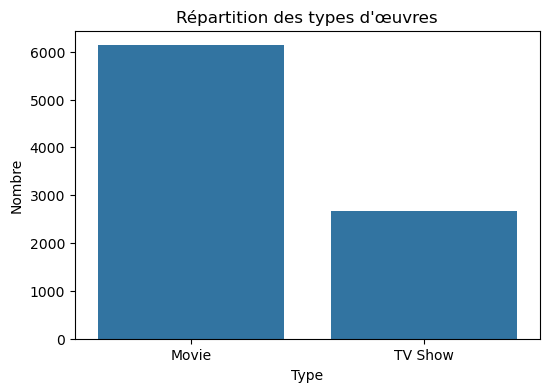

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type')
plt.title("Répartition des types d'œuvres")
plt.xlabel("Type")
plt.ylabel("Nombre")
plt.show()

b. Par pays 

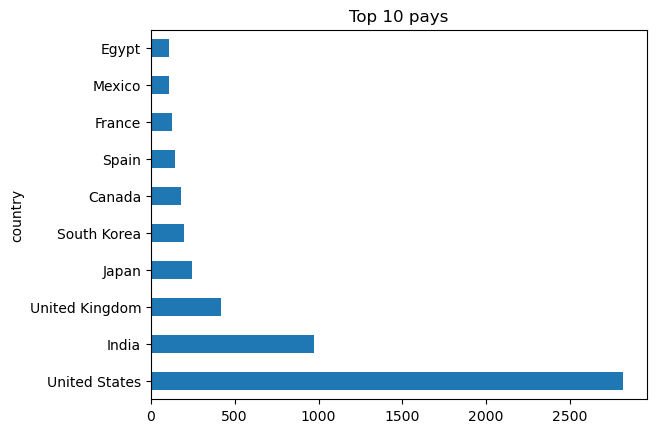

In [27]:
df['country'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 pays")
plt.show()

c. Par année

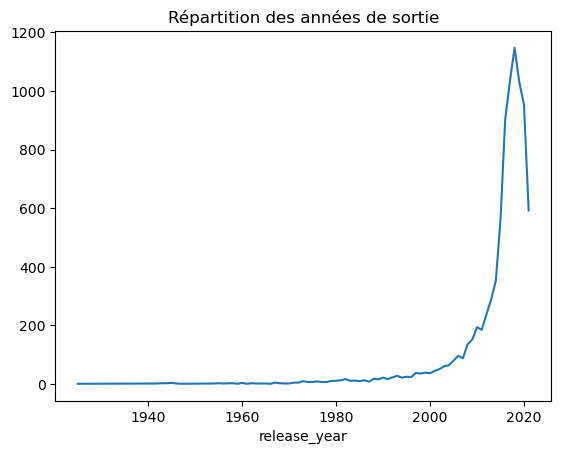

In [28]:
df['release_year'].value_counts().sort_index().plot()
plt.title("Répartition des années de sortie")
plt.show()

d. Par rating

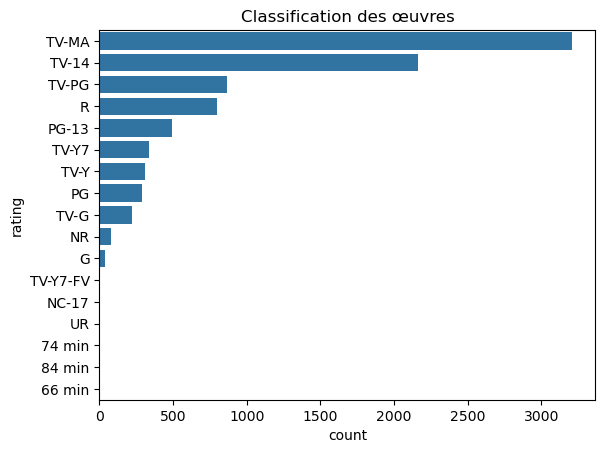

In [29]:
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Classification des œuvres")
plt.show()

e. Durée des films 

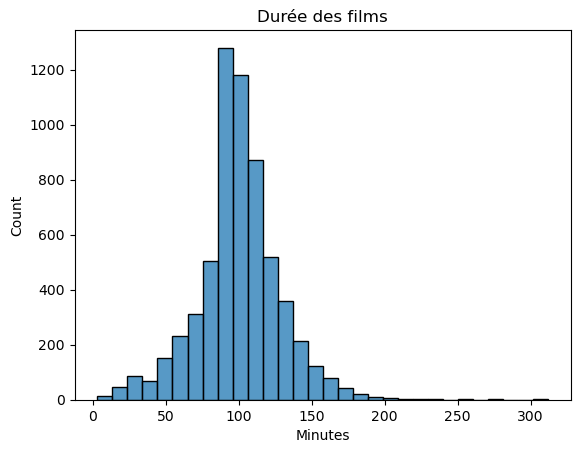

In [30]:
sns.histplot(df[df['type'] == 'Movie']['duration_int'].dropna(), bins=30)
plt.title("Durée des films")
plt.xlabel("Minutes")
plt.show()

f. Durée des séries

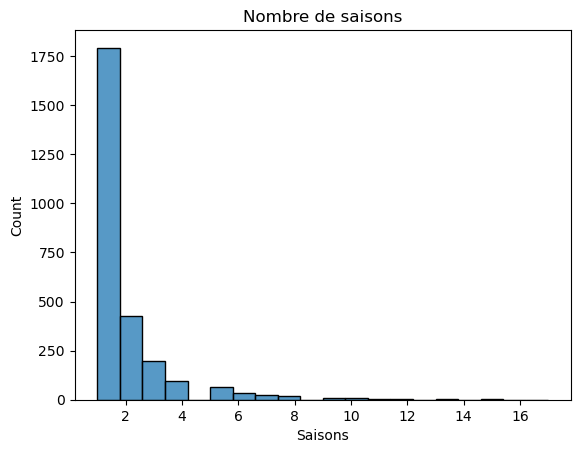

In [31]:
sns.histplot(df[df['type'] == 'TV Show']['duration_int'].dropna(), bins=20)
plt.title("Nombre de saisons")
plt.xlabel("Saisons")
plt.show()

g. Genres

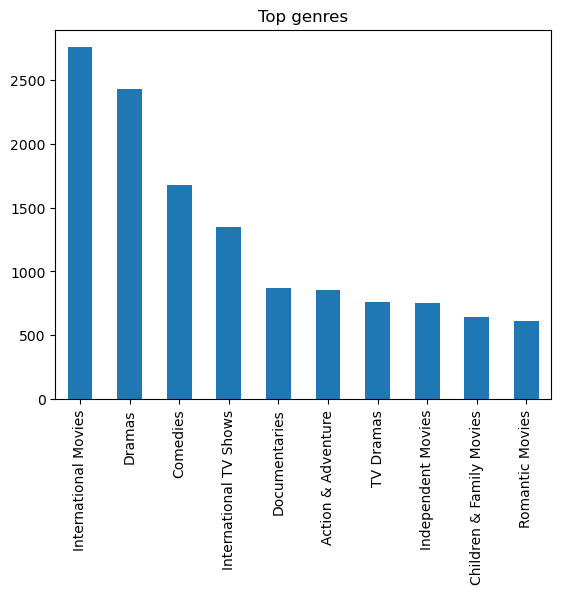

In [32]:
from collections import Counter
genre_counts = Counter(df['listed_in_list'].explode())
pd.Series(genre_counts).sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top genres")
plt.show()

h. Top 5 séries les plus longues 

In [33]:
print(df[df['type'] == 'TV Show'].sort_values('duration_int', ascending=False).head(5)[['title', 'duration']])

                       title    duration
548           Grey's Anatomy  17 Seasons
2423            Supernatural  15 Seasons
4798                    NCIS  15 Seasons
1354               Heartland  13 Seasons
4220  COMEDIANS of the world  13 Seasons


i. Top 5 films les plus long

In [34]:
print(df[df['type'] == 'Movie'].sort_values('duration_int', ascending=False).head(5)[['title', 'duration']])

                            title duration
4253   Black Mirror: Bandersnatch  312 min
717   Headspace: Unwind Your Mind  273 min
2491       The School of Mischief  253 min
2487               No Longer kids  237 min
2484           Lock Your Girls In  233 min


j. Répartitions des réalisateurs français

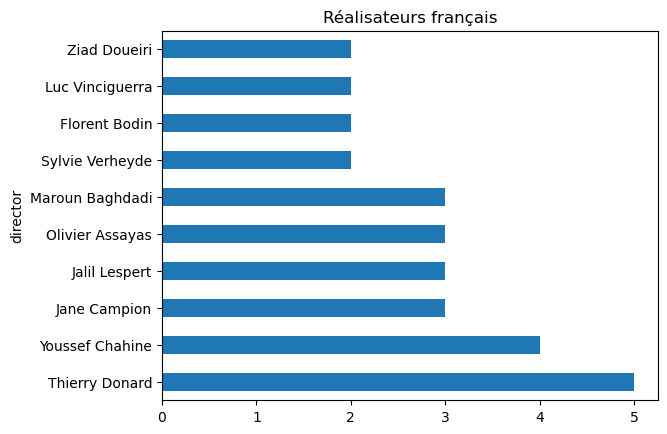

In [35]:
df_fr = df[df['country'].str.contains('France', na=False)]
df_fr['director'].value_counts().head(10).plot(kind='barh')
plt.title("Réalisateurs français")
plt.show()

k. Par année d'ajout 

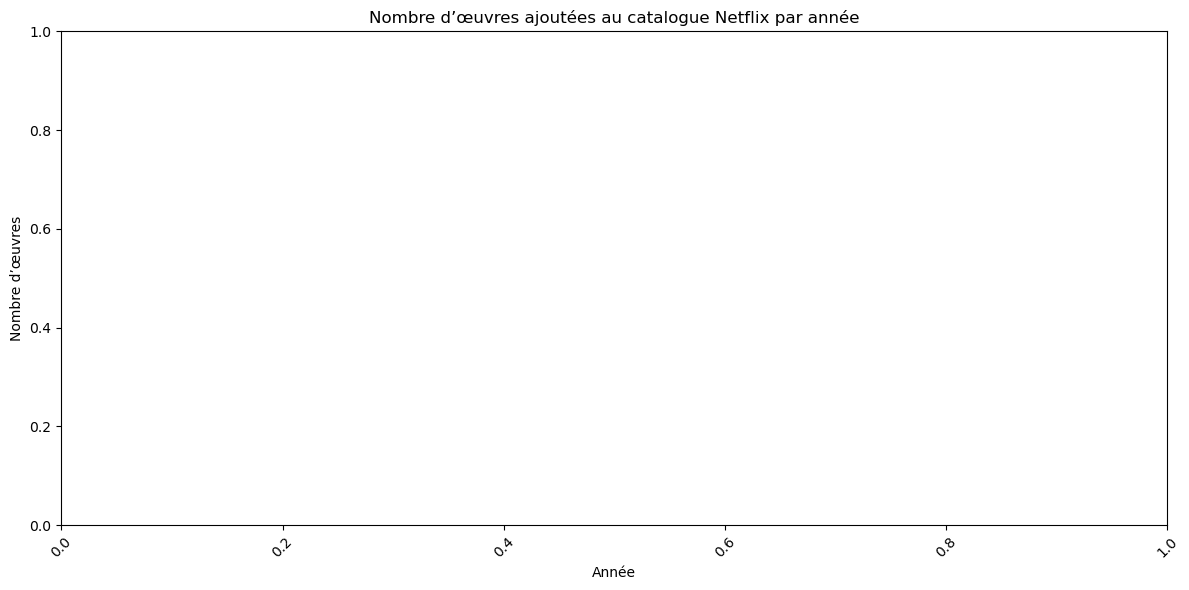

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.title("Nombre d’œuvres ajoutées au catalogue Netflix par année")
plt.xlabel("Année")
plt.ylabel("Nombre d’œuvres")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
